Triangle plot for NSNS optimized rates

In [1]:
# let's import things
import h5py as h5 
import pandas as pd
from astropy.table import Table
from astropy import units as u
from astropy import constants as const
import numpy as np
import matplotlib.pyplot as plt
plt.rc('text.latex', preamble=r'\usepackage{textgreek}')
plt.rc('font', family='serif')
import sys
import os
from scipy import stats
import seaborn as sns
import matplotlib as mpl

# Add the subdir to sys.path
sys.path.append('/home/jovyan/home/research_work/useful_py_scripts/')

# Now you can import the module
import useful_fncs 

# import for axes labels 
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "sans-serif"
})

In [3]:
# let's first look at the NSNS_output

# the average_SF_mass_needed is Average_SF_mass_needed =  10892909.034667056

pathToH5_NSNS = '/home/jovyan/home/copied_files/N1e6_NSNS_Fid/COMPAS_Output_wWeights.h5'

Data_NSNS  = h5.File(pathToH5_NSNS, "r")

DCOs_NSNS = Data_NSNS['BSE_Double_Compact_Objects'] # getting the DCO objects

# gathering the double compact objects that we have computed rates for
DCO_mask_NSNS = Data_NSNS['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['DCOmask'][()]

# times (these should be in Myr)
lifetimes_all = DCOs_NSNS['Time'][()]
lifetimes = lifetimes_all[DCO_mask_NSNS]

col_times_all = DCOs_NSNS['Coalescence_Time'][()]
col_times = col_times_all[DCO_mask_NSNS]

# this should hypothetically be the DCO systems that merge within a hubble time (since DCO mask was applied) 
delay_times = lifetimes + col_times

In [10]:
# let's plot the rate of the systems that merge within a hubble time

hubble_time = 13.9e3
condition_mergers = delay_times < hubble_time
mergers = np.sum(condition_mergers)

# mixture_weights_merged = mixture_weights[condition_mergers]

rates_z0_DCO = Data_NSNS['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['merger_rate_z0'][()]
rates_DCO_masked = rates_z0_DCO[condition_mergers]


# selecting for NSNS
stellar_types_all_1 = DCOs_NSNS['Stellar_Type(1)'][()]
stellar_types_1 = stellar_types_all_1[DCO_mask_NSNS]
stellar_types_1_merged = stellar_types_1[condition_mergers]

stellar_types_all_2 = DCOs_NSNS['Stellar_Type(2)'][()]
stellar_types_2 = stellar_types_all_2[DCO_mask_NSNS]
stellar_types_2_merged = stellar_types_2[condition_mergers]

In [11]:
# let's now do this for the WDWD systems 

HeWD_bool,COWD_bool,ONeWD_bool,HeCOWD_bool,HeONeWD_bool,COHeWD_bool,COONeWD_bool,ONeHeWD_bool,ONeCOWD_bool = useful_fncs.WD_BINARY_BOOLS(stellar_types_1_merged, stellar_types_2_merged)
carbon_oxygen_bool = np.logical_or(ONeCOWD_bool,np.logical_or(COONeWD_bool,np.logical_or(COHeWD_bool,np.logical_or(COWD_bool,HeCOWD_bool))))


In [12]:
# gathering the masses
mass1_all = DCOs_NSNS['Mass(1)'][()]
mass_1 = mass1_all[DCO_mask_NSNS]
mass_1_merged = mass_1[condition_mergers]
mass_1_COWD = mass_1_merged[carbon_oxygen_bool]

mass2_all = DCOs_NSNS['Mass(2)'][()]
mass_2 = mass2_all[DCO_mask_NSNS]
mass_2_merged = mass_2[condition_mergers]
mass_2_COWD = mass_2_merged[carbon_oxygen_bool]

M1 = np.maximum(mass_1_COWD, mass_2_COWD)
M2 = np.minimum(mass_1_COWD, mass_2_COWD)


In [13]:
rates_z0_COWD = rates_DCO_masked[carbon_oxygen_bool]

Text(0.2, 1.2, 'ONeWD = oxygen-neon white dwarf')

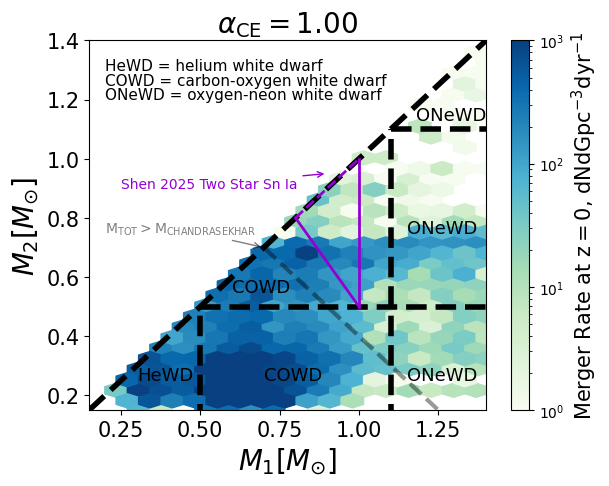

In [120]:
# let's now plot the triangle plots

fig, ax = plt.subplots()

####### Triangle plots
vmin = 1
vmax = 10**3

# for 2D histogram or 2D plots, we need to use somethign that will allow us to use a color bar so something liek pcolormesh or plt.contour or hexbin
hb = ax.hexbin(M1, M2, C=rates_z0_COWD, gridsize=(17,17), reduce_C_function = np.sum, 
                cmap=sns.color_palette("GnBu", as_cmap=True),norm='log',vmin=vmin,vmax=vmax) # C is value of weights, 1e3- 10**3
                # use symlog when you also want to cover negative values    
# right now we are not dividing by the bin size, so when we chage the bins - it changes the shape of our dist 
zvalue_array = hb.get_array() # the merger rates of the histigram 

# colorbar
cb = fig.colorbar(hb,ax=ax)
cb.set_label(label="Merger Rate at $\mathrm{z =0}$, $\mathrm{dNdGpc^{-3}dyr^{-1}}$", fontsize = 15)

max_mass_lim = 1.4
ax.set_ylim(0.15,max_mass_lim)
ax.set_xlim(0.15,max_mass_lim)

# let's add the mass restrictions for each case of binary WDs as prompted by Shen 2025

xlim = max(M1)
ylim = max(M1)

linecolors = 'black'
linewidths = 4

ax.axline((0,0), (max(M1),max(M1)), color=linecolors, ls='--', lw=linewidths, transform=plt.gca().transAxes)

#Helium WD cutoff
ax.vlines(x=[0.5], ymin=0, ymax=0.5, colors=linecolors, ls='--', lw=linewidths) # vertical line
ax.plot([0.5,max_mass_lim],[0.5,0.5],color=linecolors,lw=linewidths, ls='--') # horizontal line

#Carbon oxygen WD cutoff
ax.vlines(x=[1.1], ymin=0, ymax=1.1, colors=linecolors, ls='--', lw=linewidths) # vertical line
ax.plot([1.1,max_mass_lim],[1.1,1.1],color=linecolors,lw=linewidths, ls='--') # horizontal line

# # chandrasekar mass line
ax.plot((1.4,0.7),(0,0.7),color='black', lw=3, ls='--', alpha = 0.4)

# purple region - 2 star SN Ia
ax.plot([0.8,1],[0.8,0.5],color='darkviolet', lw=2) # bottom boundary
ax.plot([1.0,1.0],[1.0,0.5],color='darkviolet', lw=2) # side boundary
ax.plot([0.8,1.0],[0.8,1.0],color='darkviolet',ls='--', lw=2) # top boundary 


ax.tick_params(labelsize=15)
# ax.set_yticklabels(fontsize=15)
ax.set_xlabel("$M_{1}$[$M_{\odot}$]",fontsize=20)
ax.set_ylabel("$M_{2}$[$M_{\odot}$]",fontsize=20)
ax.set_title(r"$\alpha_{\mathrm{CE}}=1.00$",fontsize=20)

# annotating the text
## things with arrows
ax.annotate("Shen 2025 Two Star Sn Ia", xy=(0.9, 0.95), xytext=(0.25, 0.9), color = "darkviolet", arrowprops=dict(color='darkviolet', arrowstyle='->'))
ax.annotate("$\mathrm{M_{TOT}>M_{CHANDRASEKHAR}}$", xy=(0.7, 0.7), xytext=(0.2, 0.75), color = "black", alpha=0.5, arrowprops=dict(color='black', alpha=0.5, arrowstyle='->'))

# text without arrows
ax.text(0.30, 0.25, s='HeWD', color='black', fontsize=13) 
ax.text(0.7, 0.25, s='COWD', color='black', fontsize=13) 
ax.text(1.15, 0.25, s='ONeWD', color='black', fontsize=13) 

ax.text(0.60, 0.55, s='COWD', color='black', fontsize=13) 
ax.text(1.15, 0.75, s='ONeWD', color='black', fontsize=13) 

ax.text(1.18, 1.13, s='ONeWD', color='black', fontsize=13) 

#synthetic legend
ax.text(0.20, 1.30, s='HeWD = helium white dwarf', color='black', fontsize=11) 
ax.text(0.20, 1.25, s='COWD = carbon-oxygen white dwarf', color='black', fontsize=11) 
ax.text(0.20, 1.20, s='ONeWD = oxygen-neon white dwarf', color='black', fontsize=11) 

# # saving the figure
# plt.savefig('./triangle_plots/annotated_triangle_plot.pdf')



